# Theme Gallery

This gallery showcases all seven predefined themes on a range of charts — from
the basic chart types to research-style figures composed with `Panel` and
`Grid`. The available themes are:

| Theme | Character |
| ----- | --------- |
| `THEME.DEFAULT` | Tableau-style categorical palette, open spines, soft grid. |
| `THEME.GREYSCALE` | Monochrome, print-friendly. |
| `THEME.PUBLICATION` | Diversified YlGnBu palette with navy accents for papers. |
| `THEME.BACKGROUND` | Light gray, for de-emphasized context elements. |
| `THEME.MINIMAL` | Accent blue with deep grays, no spines, flat bars. |
| `THEME.MATERIAL` | Google palette, bottom spine only, light grid. |
| `THEME.ACADEMIC` | Serif fonts, black edges, dotted grid, hatch cycle. |

Themes now also carry *defaults for chart settings*: every theme shows a muted
y-grid unless a chart call sets `show_grid` itself, and `MINIMAL`, `MATERIAL`,
and `ACADEMIC` label bar values by default. An explicit setting always wins.

In [1]:
import math
import random

from datachart.charts import (
    BarChart,
    BoxPlot,
    Heatmap,
    Histogram,
    LineChart,
    ParallelCoords,
    ScatterChart,
)
from datachart.config import config
from datachart.constants import THEME, ORIENTATION
from datachart.utils import Grid, Panel

random.seed(42)


def ema(vals, alpha=0.35):
    out, acc = [], vals[0]
    for v in vals:
        acc = alpha * v + (1 - alpha) * acc
        out.append(acc)
    return out

## Default

The modernized default theme: a Tableau-style categorical palette, white bar
edges, no top/right spines, and a soft y-grid that comes from the theme's own
`chart_default_show_grid` — no `show_grid` argument needed.

In [2]:
config.set_theme(THEME.DEFAULT)

**Bar chart**

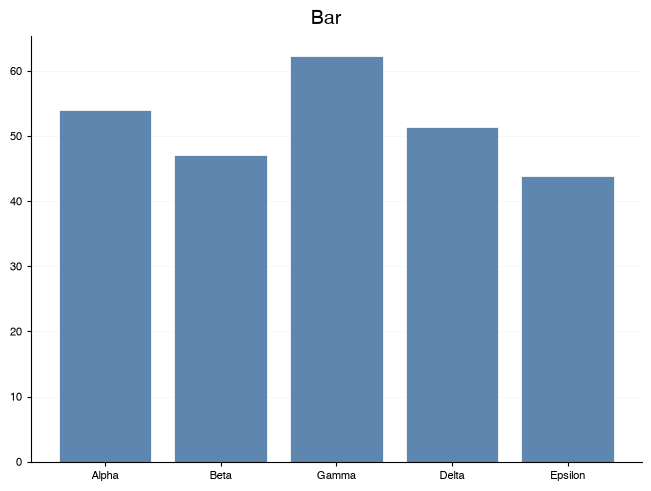

In [3]:
BAR = [
    {"label": l, "y": y}
    for l, y in zip(
        ["Alpha", "Beta", "Gamma", "Delta", "Epsilon"], [54.0, 47.1, 62.3, 51.4, 43.8]
    )
]

_ = BarChart(BAR, title="Bar")

**Line chart**

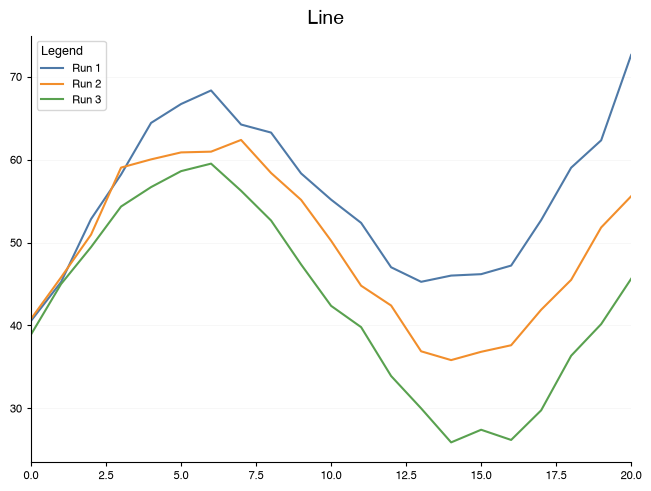

In [4]:
LINES = [
    [
        {"x": x, "y": 40 + 18 * math.sin(x / 3.2) + x * k + random.uniform(-2, 2)}
        for x in range(0, 21)
    ]
    for k in (1.6, 0.9, 0.3)
]

_ = LineChart(
    LINES, title="Line", subtitle=["Run 1", "Run 2", "Run 3"], show_legend=True
)

**Training curves with twin axes.** Raw series are faded, their trends drawn
in the same color at full strength, and validation accuracy lives on the right
y-axis via `Panel`.

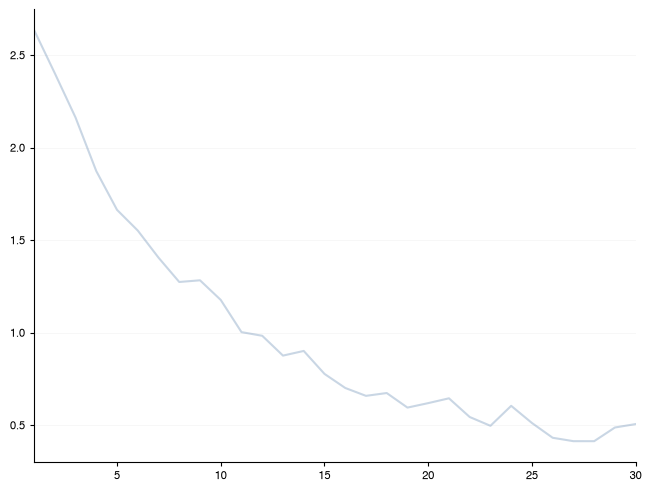

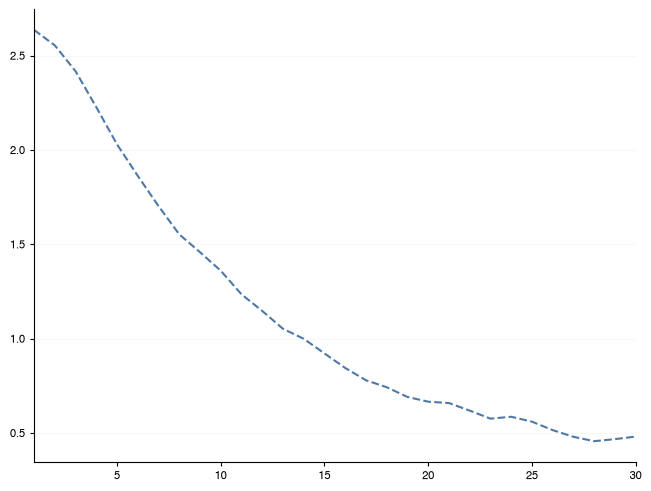

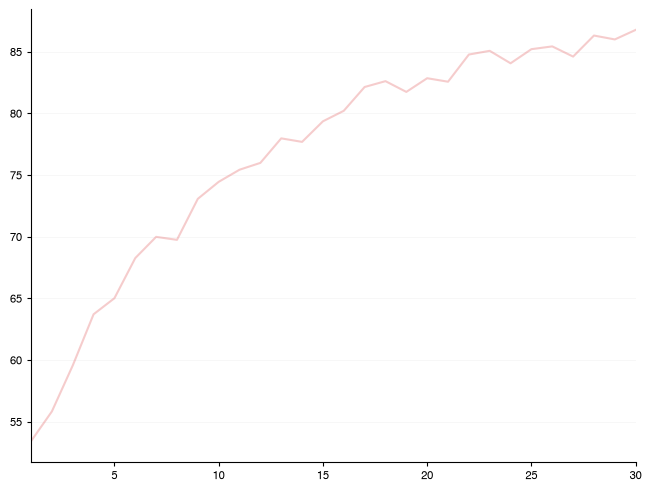

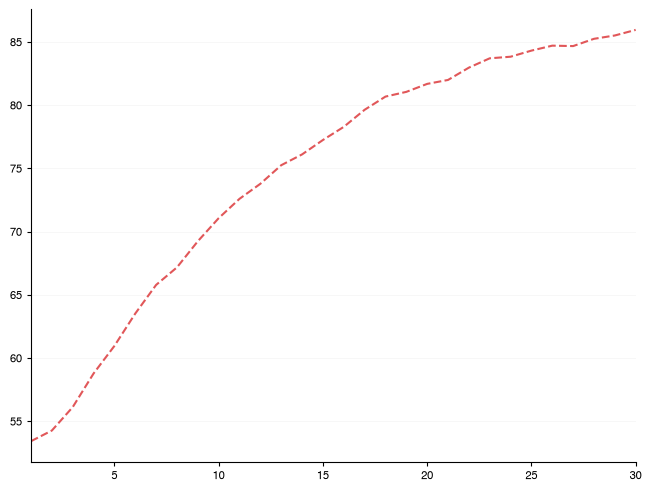

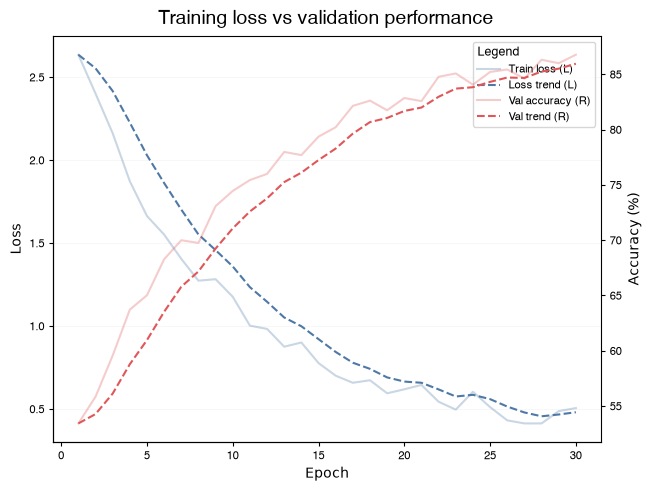

In [5]:
EPOCHS = list(range(1, 31))
TRAIN_LOSS = [
    2.5 * math.exp(-e / 8) + 0.4 + random.uniform(-0.08, 0.08) for e in EPOCHS
]
LOSS_TREND = ema(TRAIN_LOSS)
VAL_ACC = [
    50 + 38 * (1 - math.exp(-e / 10)) + random.uniform(-1.2, 1.2) for e in EPOCHS
]
VAL_TREND = ema(VAL_ACC)

c1, c2 = "#4E79A7", "#E15759"
loss = LineChart(
    [{"x": e, "y": v} for e, v in zip(EPOCHS, TRAIN_LOSS)],
    subtitle="Train loss",
    style={"plot_line_alpha": 0.3, "plot_line_color": c1},
)
loss_trend = LineChart(
    [{"x": e, "y": v} for e, v in zip(EPOCHS, LOSS_TREND)],
    subtitle="Loss trend",
    style={"plot_line_style": "--", "plot_line_color": c1},
)
val = LineChart(
    [{"x": e, "y": v} for e, v in zip(EPOCHS, VAL_ACC)],
    subtitle="Val accuracy",
    style={"plot_line_alpha": 0.3, "plot_line_color": c2},
)
val_trend = LineChart(
    [{"x": e, "y": v} for e, v in zip(EPOCHS, VAL_TREND)],
    subtitle="Val trend",
    style={"plot_line_style": "--", "plot_line_color": c2},
)
_ = Panel(
    [
        {"figure": loss, "y_axis": "left"},
        {"figure": loss_trend, "y_axis": "left"},
        {"figure": val, "y_axis": "right"},
        {"figure": val_trend, "y_axis": "right"},
    ],
    title="Training loss vs validation performance",
    xlabel="Epoch",
    ylabel_left="Loss",
    ylabel_right="Accuracy (%)",
    show_legend=True,
)

## Greyscale

Monochrome and print-friendly, with the same open spines and muted grid as the
default theme.

In [6]:
config.set_theme(THEME.GREYSCALE)

**Ablation study.** Diverging horizontal bars with value labels; the engine
adds headroom on both ends so the labels stay inside the axes.

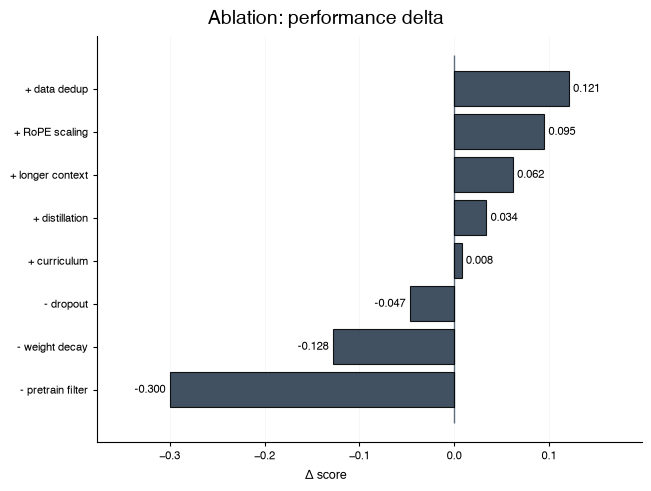

In [7]:
ABLATION = [
    {"label": l, "y": y}
    for l, y in sorted(
        [
            ("+ data dedup", 0.121),
            ("+ RoPE scaling", 0.095),
            ("+ longer context", 0.062),
            ("+ distillation", 0.034),
            ("+ curriculum", 0.008),
            ("- dropout", -0.047),
            ("- weight decay", -0.128),
            ("- pretrain filter", -0.300),
        ],
        key=lambda t: t[1],
    )
]

_ = BarChart(
    ABLATION,
    title="Ablation: performance delta",
    orientation=ORIENTATION.HORIZONTAL,
    show_values=True,
    value_format="%.3f",
    xlabel="Δ score",
    show_grid="x",
    vlines={
        "x": 0,
        "style": {
            "plot_vline_width": 1.0,
            "plot_vline_style": "-",
            "plot_vline_alpha": 1.0,
        },
    },
)

**Probability distributions**

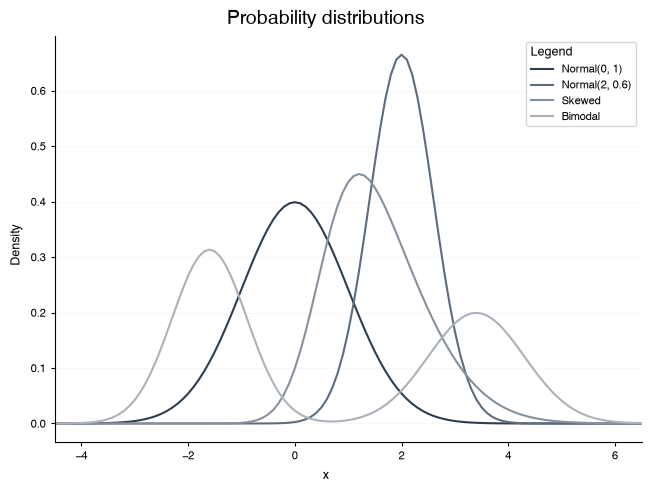

In [8]:
DIST_X = [i / 10 for i in range(-45, 66)]


def npdf(x, mu, sd):
    return math.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * math.sqrt(2 * math.pi))


DISTS = {
    "Normal(0, 1)": [{"x": x, "y": npdf(x, 0, 1)} for x in DIST_X],
    "Normal(2, 0.6)": [{"x": x, "y": npdf(x, 2, 0.6)} for x in DIST_X],
    "Skewed": [
        {
            "x": x,
            "y": 2
            * npdf(x, 0.5, 1.4)
            * (0.5 * (1 + math.erf(2.5 * (x - 0.5) / 1.4 / math.sqrt(2)))),
        }
        for x in DIST_X
    ],
    "Bimodal": [
        {"x": x, "y": 0.55 * npdf(x, -1.6, 0.7) + 0.45 * npdf(x, 3.4, 0.9)}
        for x in DIST_X
    ],
}

_ = LineChart(
    list(DISTS.values()),
    subtitle=list(DISTS.keys()),
    title="Probability distributions",
    xlabel="x",
    ylabel="Density",
    show_legend=True,
)

## Publication

A diversified YlGnBu palette with navy edges, tuned for figures that go into
papers. The `COLORS.PaperYlGnBu` and `COLORS.PaperAccent` palettes carry the
same colors for use outside this theme.

In [9]:
config.set_theme(THEME.PUBLICATION)

**Scatter chart**

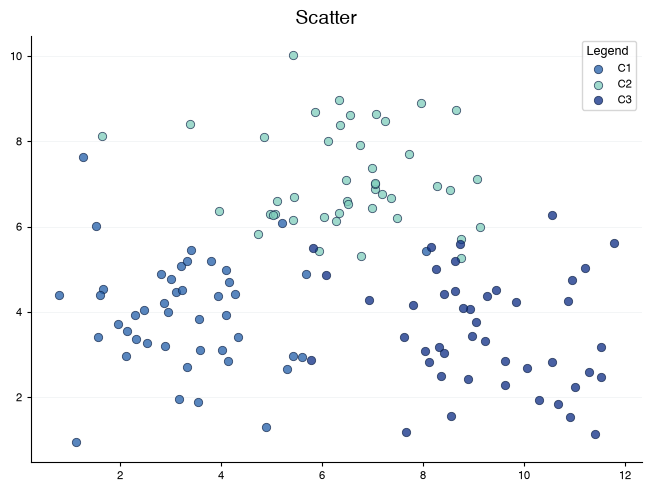

In [10]:
SCATTER = [
    [{"x": random.gauss(mx, 1.4), "y": random.gauss(my, 1.2)} for _ in range(45)]
    for mx, my in ((3, 4), (6.5, 7), (9, 3.5))
]

_ = ScatterChart(
    SCATTER, title="Scatter", subtitle=["C1", "C2", "C3"], show_legend=True
)

**Pareto front.** Scatter families overlaid with the frontier line via `Panel`.

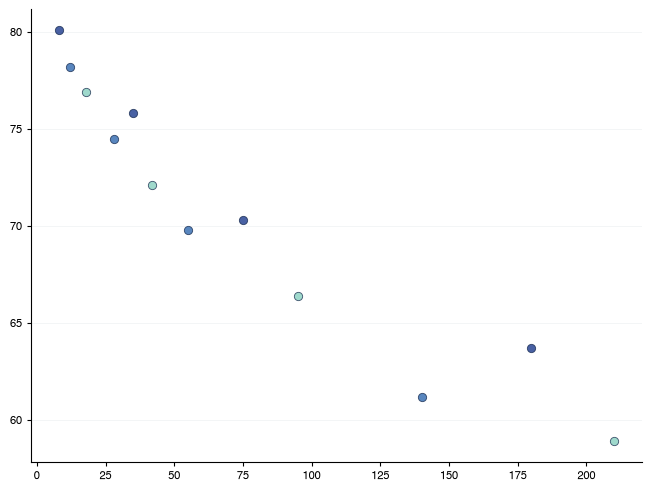

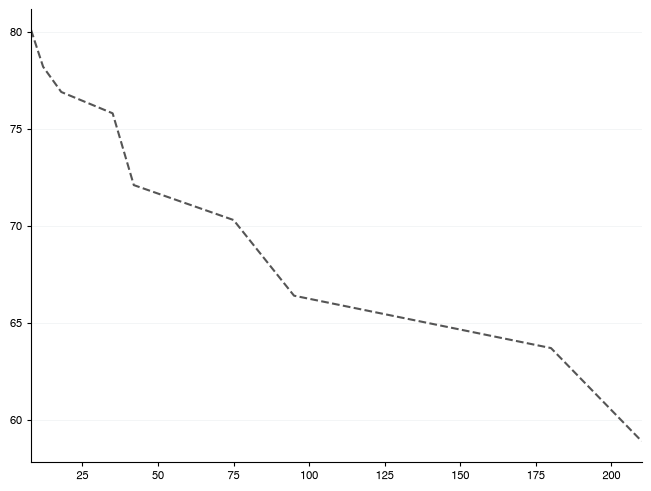

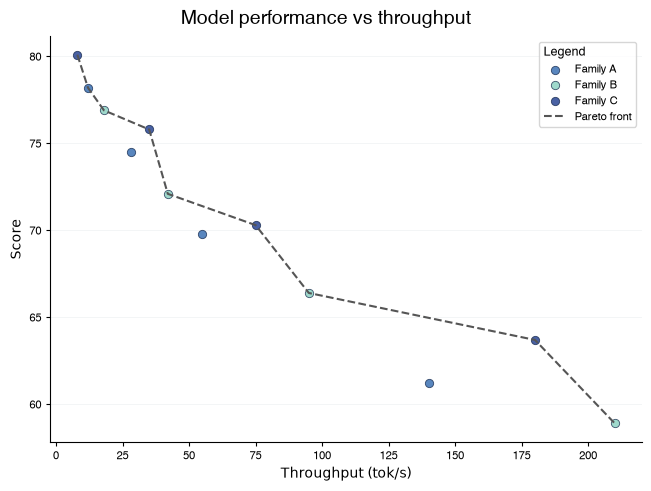

In [11]:
PARETO_FAMILIES = {
    "Family A": [(12, 78.2), (28, 74.5), (55, 69.8), (140, 61.2)],
    "Family B": [(18, 76.9), (42, 72.1), (95, 66.4), (210, 58.9)],
    "Family C": [(8, 80.1), (35, 75.8), (75, 70.3), (180, 63.7)],
}
PARETO_SCATTER = [
    [{"x": x, "y": y} for x, y in pts] for pts in PARETO_FAMILIES.values()
]
all_points = [p for pts in PARETO_FAMILIES.values() for p in pts]
PARETO_FRONT = [
    {"x": x, "y": y}
    for x, y in sorted(all_points)
    if not any(ox >= x and oy > y for ox, oy in all_points if (ox, oy) != (x, y))
]

families = ScatterChart(PARETO_SCATTER, subtitle=list(PARETO_FAMILIES.keys()))
front = LineChart(
    PARETO_FRONT,
    subtitle="Pareto front",
    style={"plot_line_style": "--", "plot_line_color": "#555555"},
)
_ = Panel(
    [families, front],
    title="Model performance vs throughput",
    xlabel="Throughput (tok/s)",
    ylabel_left="Score",
    show_legend=True,
)

**Empirical ROC curves** with a chance diagonal.

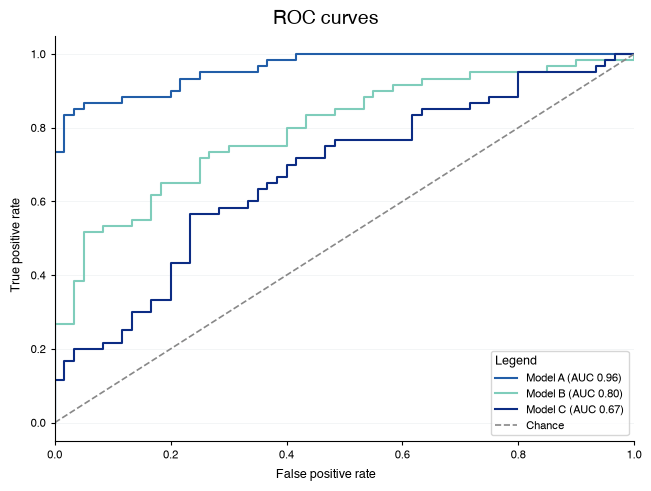

In [12]:
def empirical_roc(sep, n=60):
    pos = sorted(random.gauss(sep, 1) for _ in range(n))
    neg = sorted(random.gauss(0, 1) for _ in range(n))
    scores = sorted(set(pos + neg), reverse=True)
    pts, auc_pairs = [{"x": 0.0, "y": 0.0}], 0
    for th in scores:
        tpr = sum(p >= th for p in pos) / n
        fpr = sum(g >= th for g in neg) / n
        pts.append({"x": fpr, "y": tpr})
    for p in pos:
        auc_pairs += sum(p > g for g in neg) + 0.5 * sum(p == g for g in neg)
    return pts, auc_pairs / (n * n)


ROC_CURVES, ROC_LABELS = [], []
for name, sep in zip("ABC", (2.2, 1.3, 0.5)):
    pts, auc = empirical_roc(sep)
    ROC_CURVES.append(pts)
    ROC_LABELS.append(f"Model {name} (AUC {auc:.2f})")
ROC_CHANCE = [{"x": 0, "y": 0}, {"x": 1, "y": 1}]

_ = LineChart(
    ROC_CURVES + [ROC_CHANCE],
    subtitle=ROC_LABELS + ["Chance"],
    style=[{"plot_line_drawstyle": "steps-post"}] * len(ROC_CURVES)
    + [{"plot_line_style": "--", "plot_line_color": "#888888", "plot_line_width": 1.2}],
    title="ROC curves",
    xlabel="False positive rate",
    ylabel="True positive rate",
    show_legend=True,
)

**Log-log scaling law**

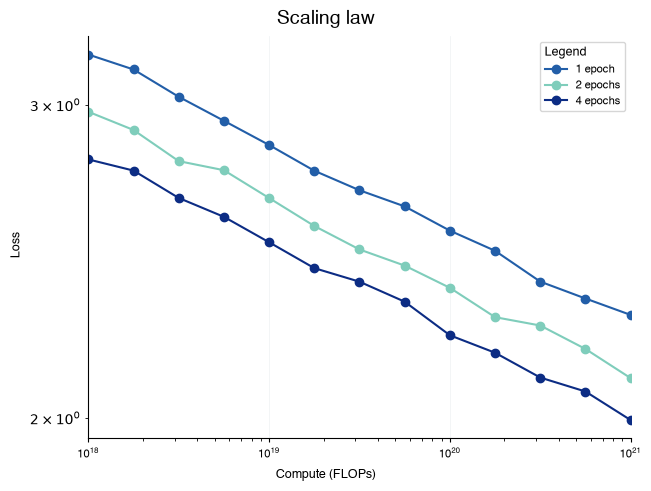

In [13]:
SCALING = [
    [
        {
            "x": 10**c,
            "y": (3.2 * (10**c / 1e18) ** -0.05)
            * f
            * (1 + random.uniform(-0.01, 0.01)),
        }
        for c in [18 + 0.25 * i for i in range(13)]
    ]
    for f in (1.0, 0.93, 0.88)
]

_ = LineChart(
    SCALING,
    subtitle=["1 epoch", "2 epochs", "4 epochs"],
    title="Scaling law",
    xlabel="Compute (FLOPs)",
    ylabel="Loss",
    scalex="log",
    scaley="log",
    show_grid="both",
    show_legend=True,
    style=[{"plot_line_marker": "o"}] * 3,
)

## Minimal

An accent blue with deep grays, no spines or tick marks, and flat bars. Bar
value labels are on by default (`chart_default_show_values`); pass
`show_values=False` where they would clutter the chart.

In [14]:
config.set_theme(THEME.MINIMAL)

**Histogram**

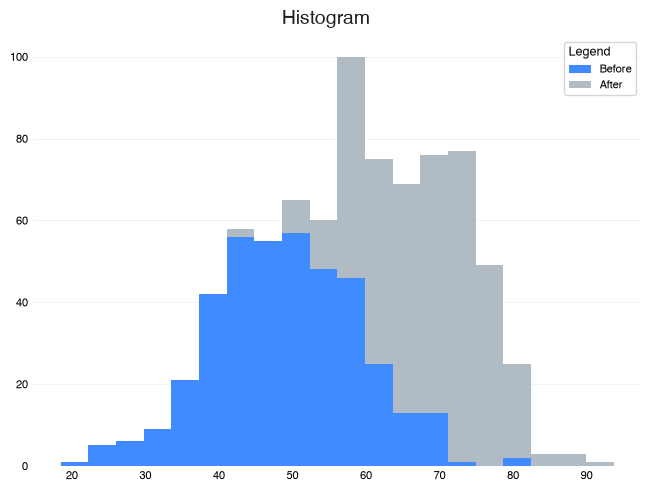

In [15]:
HIST = [
    [{"x": random.gauss(50, 10)} for _ in range(400)],
    [{"x": random.gauss(68, 8)} for _ in range(400)],
]

_ = Histogram(HIST, title="Histogram", subtitle=["Before", "After"], show_legend=True)

**Time-series forecast.** Observed data, its EMA, and a forecast horizon.

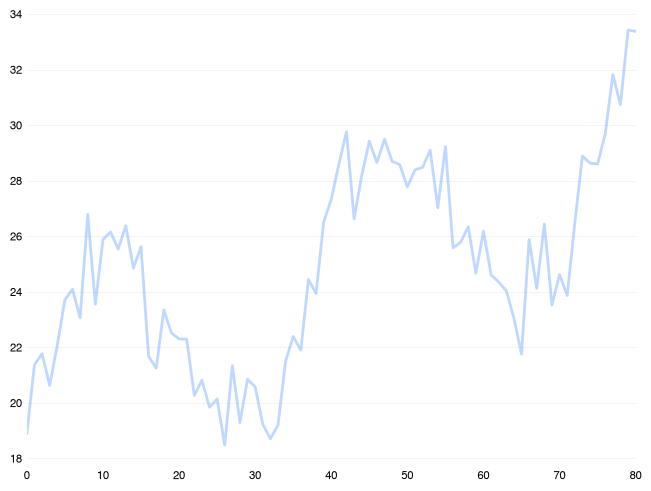

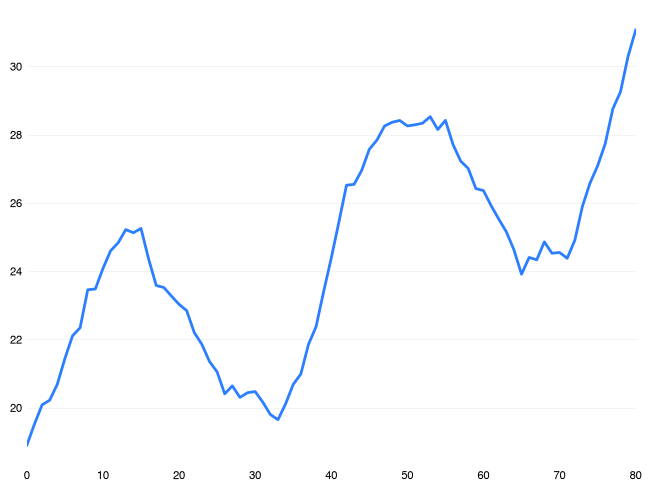

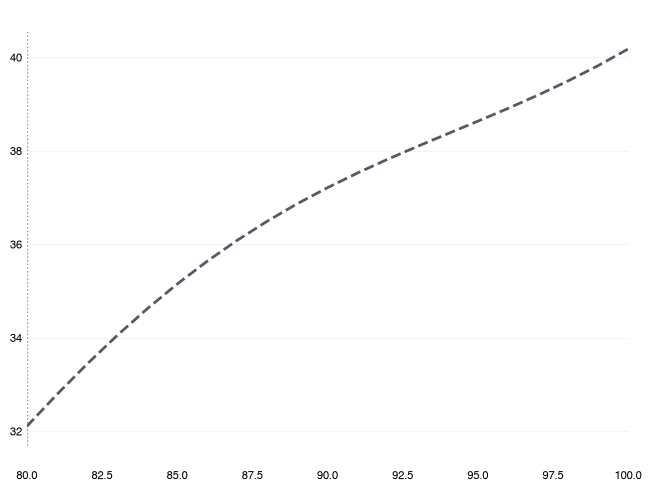

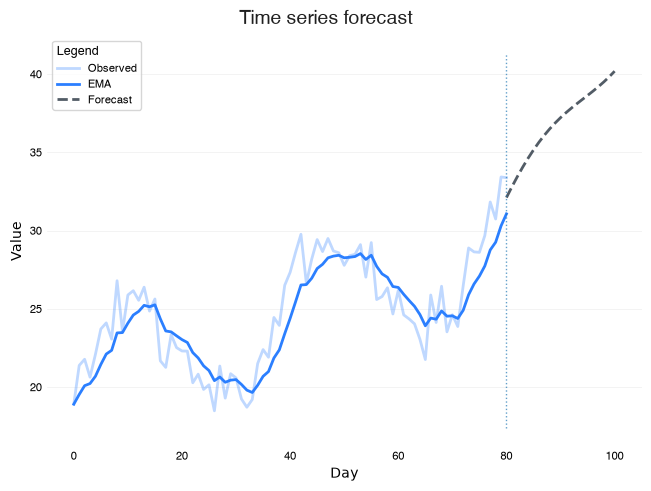

In [16]:
TS_X = list(range(0, 81))
TS_RAW = [
    20 + 0.12 * t + 4 * math.sin(t / 6) + random.uniform(-2.2, 2.2) for t in TS_X
]
TS_EMA = ema(TS_RAW, alpha=0.25)
FC_X = list(range(80, 101))
slope = (TS_EMA[-1] - TS_EMA[-13]) / 12
TS_FORECAST = [TS_EMA[-1] + slope * (t - 80) + 1.5 * math.sin(t / 6) for t in FC_X]

c1, c2 = "#2B7FFF", "#525C66"
raw = LineChart(
    [{"x": t, "y": v} for t, v in zip(TS_X, TS_RAW)],
    subtitle="Observed",
    style={"plot_line_alpha": 0.3, "plot_line_color": c1},
)
smoothed = LineChart(
    [{"x": t, "y": v} for t, v in zip(TS_X, TS_EMA)],
    subtitle="EMA",
    style={"plot_line_color": c1},
)
forecast = LineChart(
    [{"x": t, "y": v} for t, v in zip(FC_X, TS_FORECAST)],
    subtitle="Forecast",
    style={"plot_line_style": "--", "plot_line_color": c2},
    vlines={"x": 80, "style": {"plot_vline_style": ":"}},
)
_ = Panel(
    [raw, smoothed, forecast],
    title="Time series forecast",
    xlabel="Day",
    ylabel_left="Value",
    show_legend=True,
)

**Stacked bars**

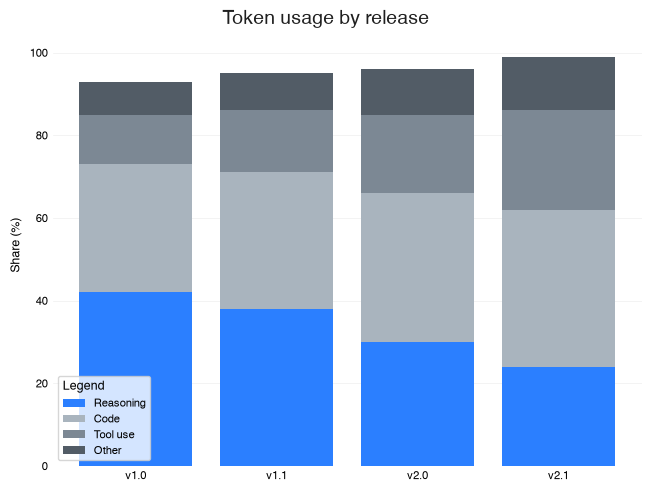

In [17]:
STACKED = [
    [{"label": r, "y": y} for r, y in zip(["v1.0", "v1.1", "v2.0", "v2.1"], ys)]
    for ys in ([42, 38, 30, 24], [31, 33, 36, 38], [12, 15, 19, 24], [8, 9, 11, 13])
]

_ = BarChart(
    STACKED,
    title="Token usage by release",
    subtitle=["Reasoning", "Code", "Tool use", "Other"],
    bar_mode="stack",
    show_values=False,
    show_legend=True,
    ylabel="Share (%)",
)

## Material

The Google palette with a bottom spine only and a light solid grid. Like
`MINIMAL`, bar value labels default to on.

In [18]:
config.set_theme(THEME.MATERIAL)

**Bars with error bars.** Benchmark mean ± std over seeds.

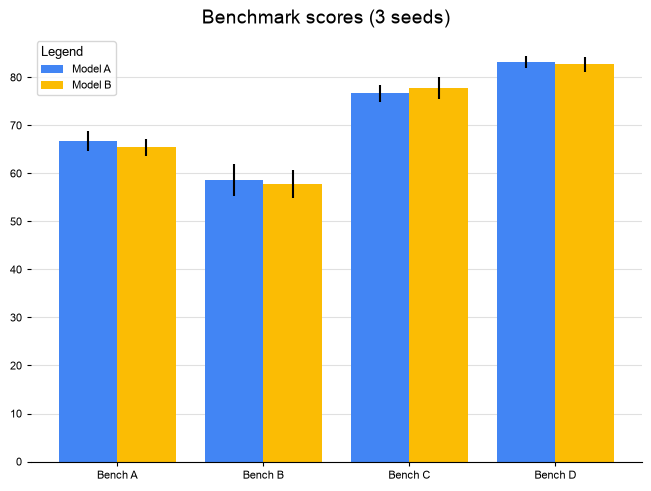

In [19]:
CATS = ["Bench A", "Bench B", "Bench C", "Bench D"]
ERRBAR = [
    [{"label": c, "y": y, "yerr": e} for c, y, e in zip(CATS, ys, es)]
    for ys, es in (
        ([66.7, 58.6, 76.7, 83.2], [2.1, 3.4, 1.8, 1.2]),
        ([65.4, 57.7, 77.8, 82.7], [1.7, 2.9, 2.3, 1.5]),
    )
]

_ = BarChart(
    ERRBAR,
    title="Benchmark scores (3 seeds)",
    subtitle=["Model A", "Model B"],
    show_yerr=True,
    show_values=False,
    show_legend=True,
)

**Score-colored parallel coordinates.** A numeric `hue` column colors each
line continuously along the theme's sequential ramp
(`color_parallel_hue_continuous`).

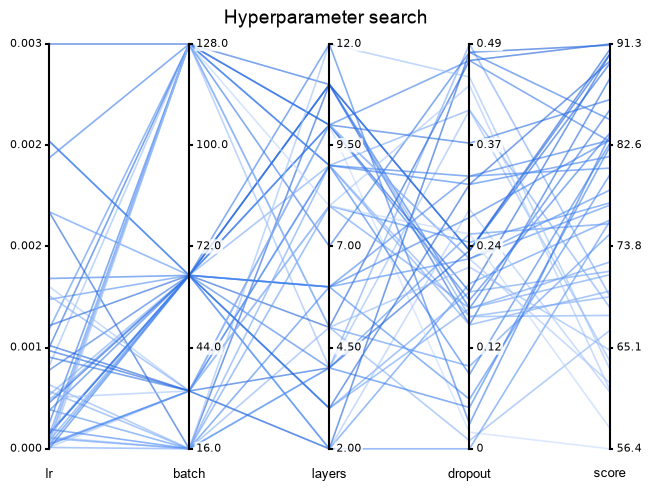

In [20]:
PARCOORD = [
    {
        "lr": round(10 ** random.uniform(-4.3, -2.5), 5),
        "batch": random.choice([16, 32, 64, 128]),
        "layers": random.randint(2, 12),
        "dropout": round(random.uniform(0.0, 0.5), 2),
        "score": round(random.uniform(55, 92), 1),
    }
    for _ in range(45)
]

_ = ParallelCoords(
    PARCOORD,
    title="Hyperparameter search",
    dimensions=["lr", "batch", "layers", "dropout", "score"],
    hue="score",
)

**Small multiples via `Grid`.** One overview chart plus a grid of details.

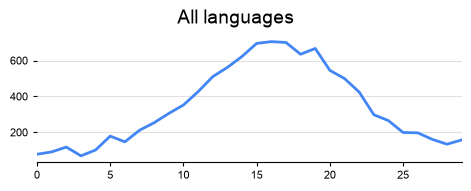

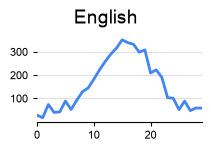

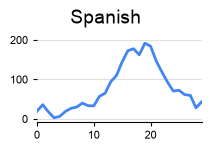

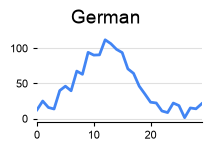

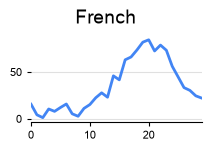

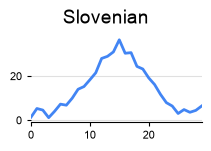

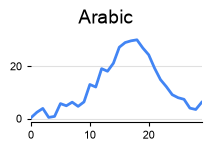

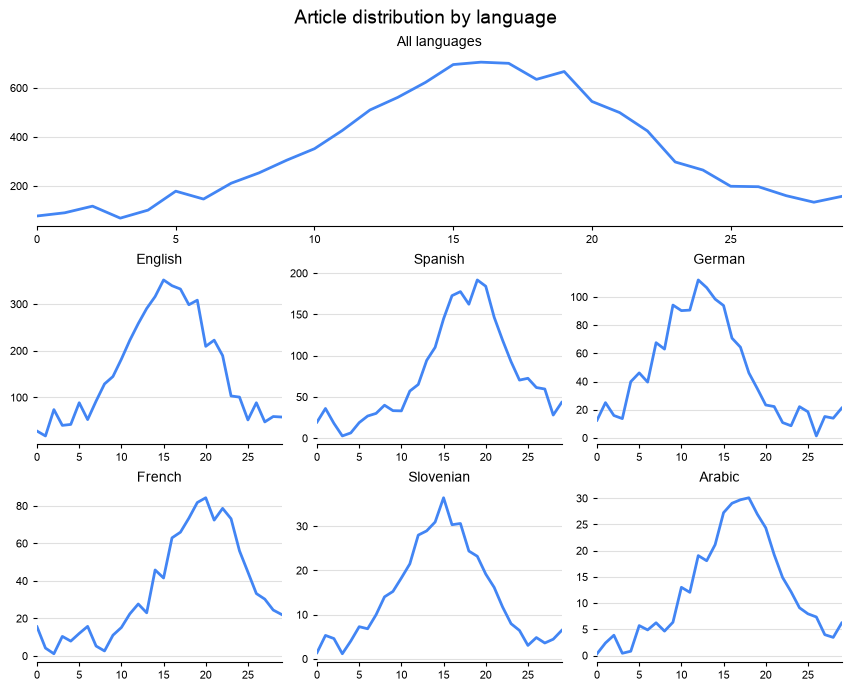

In [21]:
SM_X = list(range(30))


def sm_series(peak, scale):
    return [
        {
            "x": t,
            "y": max(
                0.0,
                scale * math.exp(-((t - peak) ** 2) / 40)
                + random.uniform(0, scale * 0.25),
            ),
        }
        for t in SM_X
    ]


SM_CATS = {
    "English": (16, 300),
    "Spanish": (18, 160),
    "German": (12, 90),
    "French": (20, 70),
    "Slovenian": (15, 30),
    "Arabic": (17, 25),
}
SM_SERIES = {name: sm_series(p, sc) for name, (p, sc) in SM_CATS.items()}
SM_TOTAL = [{"x": t, "y": sum(s[t]["y"] for s in SM_SERIES.values())} for t in SM_X]

total = LineChart(SM_TOTAL, title="All languages", figsize=(4.6, 1.8))
smalls = [
    LineChart(pts, title=cat, figsize=(2.0, 1.4)) for cat, pts in SM_SERIES.items()
]
_ = Grid(
    [[total], smalls[:3], smalls[3:]],
    title="Article distribution by language",
    figsize=(8.4, 6.8),
)

## Academic

Serif typography, black edges, a dotted grid, and a hatch cycle: multi-series
bars and histograms pick up `""`, `"//"`, `".."` hatches automatically, so the
series stay distinguishable in black-and-white print.

In [22]:
config.set_theme(THEME.ACADEMIC)

**Grouped bar chart** — the hatch cycle comes from the theme.

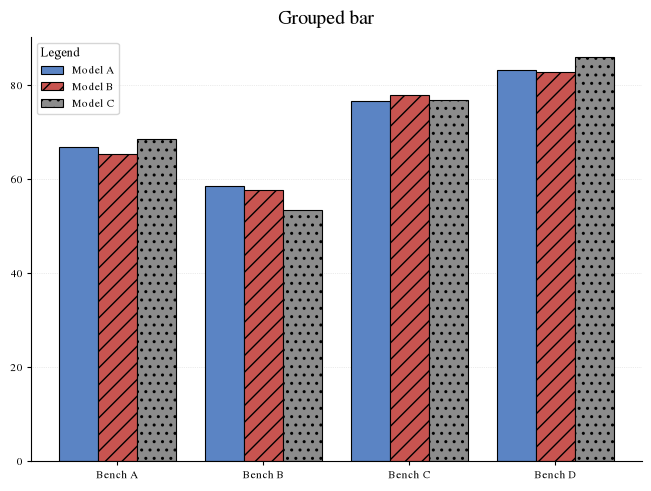

In [23]:
GROUPED = [
    [{"label": c, "y": y} for c, y in zip(CATS, [66.7, 58.6, 76.7, 83.2])],
    [{"label": c, "y": y} for c, y in zip(CATS, [65.4, 57.7, 77.8, 82.7])],
    [{"label": c, "y": y} for c, y in zip(CATS, [68.5, 53.4, 76.9, 85.9])],
]

_ = BarChart(
    GROUPED,
    title="Grouped bar",
    subtitle=["Model A", "Model B", "Model C"],
    show_values=False,
    show_legend=True,
)

**Heatmap.** Heatmaps always draw a full frame, and value labels switch to
white on dark cells automatically.

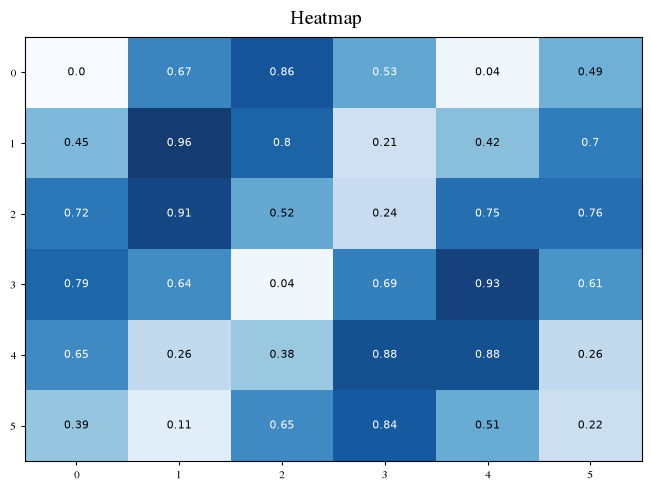

In [24]:
HEAT = [
    [
        round(abs(math.sin(0.5 * i + 0.8 * j)) * (1 - 0.07 * abs(i - j)), 2)
        for j in range(6)
    ]
    for i in range(6)
]

_ = Heatmap(HEAT, title="Heatmap", show_heatmap_values=True)

**Box plot**

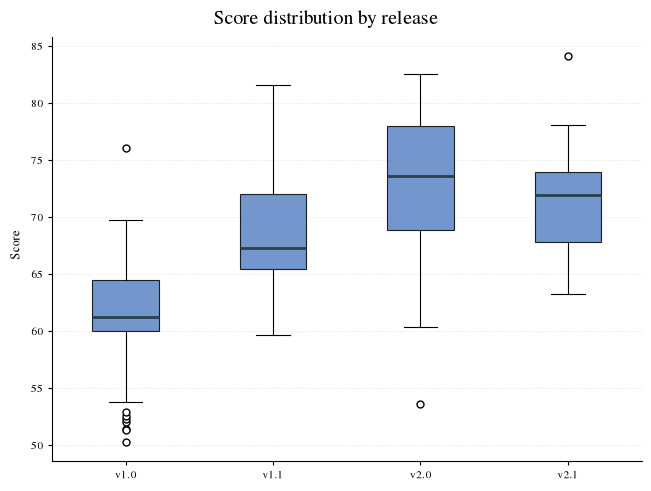

In [25]:
BOX = [
    {"label": g, "value": random.gauss(mu, sd)}
    for g, mu, sd in (
        ("v1.0", 62, 6),
        ("v1.1", 68, 5),
        ("v2.0", 74, 7),
        ("v2.1", 71, 4),
    )
    for _ in range(60)
]

_ = BoxPlot(
    BOX, title="Score distribution by release", ylabel="Score", show_outliers=True
)

**Regression with a confidence interval**

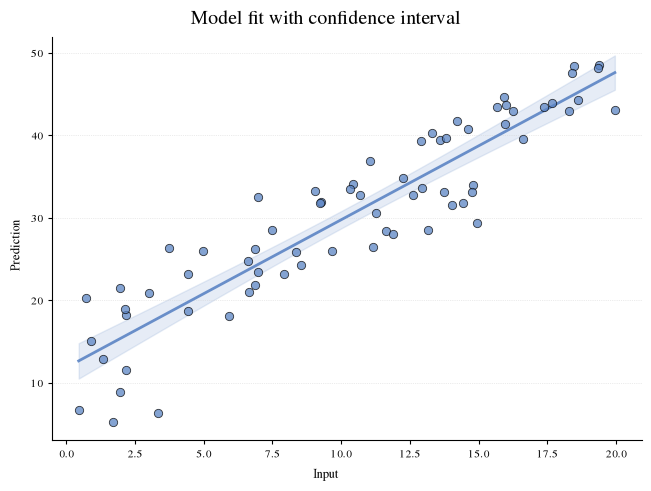

In [26]:
REG = [
    {"x": x, "y": 12 + 1.8 * x + random.gauss(0, 4.5)}
    for x in [random.uniform(0, 20) for _ in range(70)]
]

_ = ScatterChart(
    REG,
    title="Model fit with confidence interval",
    xlabel="Input",
    ylabel="Prediction",
    show_regression=True,
    show_ci=True,
)

## Background

The background theme de-emphasizes whatever is drawn with it. Because figures
snapshot their style when they are built, a `Panel` can combine faded
background context with fully-styled foreground marks — here, random walks
pinned through waypoints.

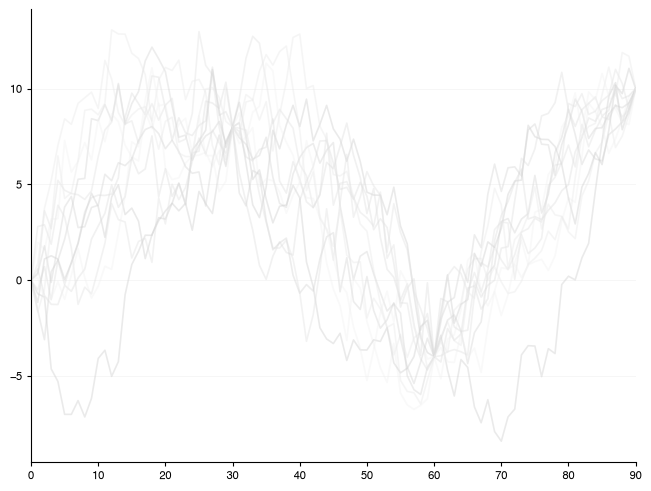

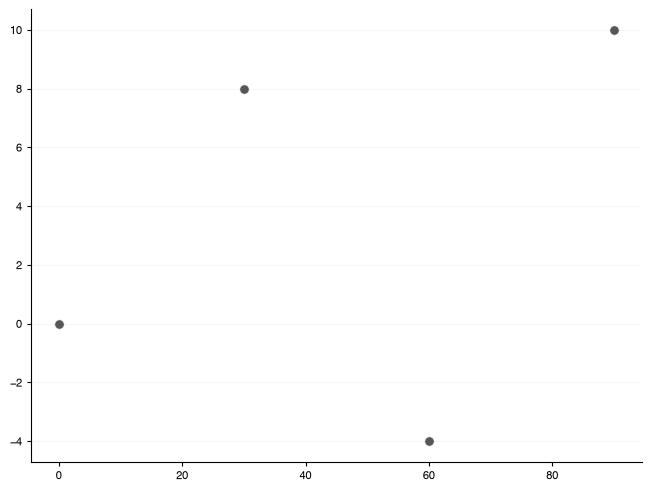

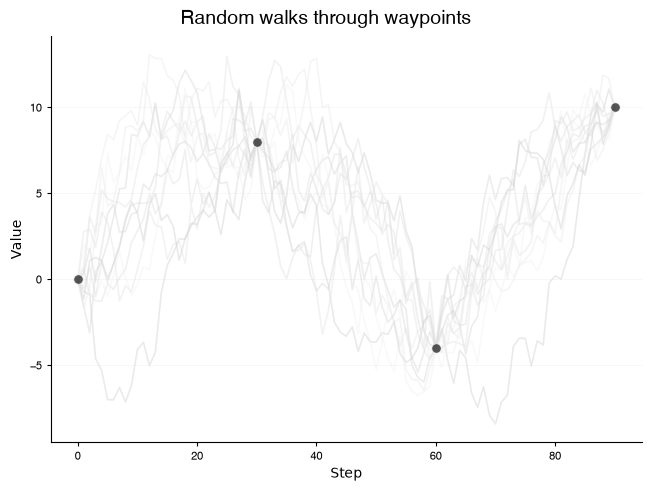

In [27]:
WAYPOINTS = [(0, 0.0), (30, 8.0), (60, -4.0), (90, 10.0)]


def bridge(t0, v0, t1, v1, sigma=1.4):
    """One Brownian-bridge segment from (t0, v0) to (t1, v1)."""
    pts, v, n = [], v0, t1 - t0
    for i in range(n):
        remaining = n - i
        drift = (v1 - v) / remaining
        v += drift + sigma * random.gauss(0, 1) * math.sqrt((remaining - 1) / remaining)
        pts.append({"x": t0 + i + 1, "y": v if remaining > 1 else v1})
    return pts


WALKS = []
for _ in range(12):
    path = [{"x": WAYPOINTS[0][0], "y": WAYPOINTS[0][1]}]
    for (t0, v0), (t1, v1) in zip(WAYPOINTS, WAYPOINTS[1:]):
        path.extend(bridge(t0, path[-1]["y"], t1, v1))
    WALKS.append(path)
WAYPOINT_PTS = [{"x": t, "y": v} for t, v in WAYPOINTS]

config.set_theme(THEME.BACKGROUND)
walks = LineChart(WALKS, subtitle=[None] * len(WALKS))

config.set_theme(THEME.DEFAULT)
pins = ScatterChart(
    WAYPOINT_PTS,
    subtitle="Waypoints",
    style={"plot_scatter_color": "#1F1F1F", "plot_scatter_size": 45},
)
_ = Panel(
    [walks, {"figure": pins, "y_axis": "left", "z_order": 5}],
    title="Random walks through waypoints",
    xlabel="Step",
    ylabel_left="Value",
)

---

Applying a theme replaces the whole global configuration, so remember to call
`config.set_theme(...)` (or `config.reset_config()`) before building the charts
it should style. See the [themes how-to](themes.ipynb) for customizing themes
attribute by attribute.

In [28]:
config.reset_config()